<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/fusemachines-2026/phase2/assignment1/tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Phase 2; Week 4
# Statistical Machine Learning: Linear Models
The Goal is to learn about linear models and machine learning pipelines

In [8]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Task 1 : Understanding the problem


In [9]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [10]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [11]:
print("Shape of X :",X.shape)
print("Shape of y:",y.shape)


Shape of X : (7043, 20)
Shape of y: (7043,)


In [12]:
X.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [13]:
X.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


## Qn 1. Formulation of Ml Problem
**Feature Space X:** X contains A matrix of Shape (7043, 20):means 7043 individual data and 20 columns or title of data; features are mix of  integer, float and mostly object(string)

**target variable:** y contains the target variable; it the the output that the model need to learn to predict; the data is binary Yes and No;

**Probablity Distrubution:** Bernouli Distrbution is used to model the target because bernouli distibution works with possible 2 outcomes success and failure(churn yes or churn no),

**about loss function:** Since the target follows a Bernoulli distribution, applying Maximum Likelihood
Estimation (MLE) to its likelihood directly derives Binary Cross-Entropyas the loss function not chosen arbitrarily, but mathematically forced by the binary nature of the target.

## Qn 2. Data-Generation Assumptions
> the dataset represents future customers

If violated, the model may learn patters from this customer mix that do not hold for new customers, regions, priccing plans, or time periods,
> Chrun is correctly labeled

If churn labels are wrong or incostient, the model learns the wrong target

> Features were measured before the churn outcome

Columns like tenure, COntract, Monthly charges and payment method must reflect the customer state before churn. If some features are recorded after the cancellation, the model may  learn future information and may overfit


In [14]:
# checking if there is null values in the data
df.isna().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
df.info()

# here only 3 columsn, SeniorCitizen, tenure and float64 is Numeric,
# linear model or any other ml models requires data to be numeric for better understaing of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
df.describe()



,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [17]:
# taking random 5 samples
df.sample(5)

# most of columns are binary yes/no type
# here totalCharges, MonthlyCharges should be float but it is registered as object

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6706,7878-RTCZG,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.90,19.9,No
22,1066-JKSGK,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
4967,4398-HSCJH,Female,0,No,No,3,Yes,Yes,DSL,No,...,No,Yes,Yes,No,Month-to-month,Yes,Electronic check,63.60,155.65,Yes
1852,3669-OYSJI,Male,0,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Credit card (automatic),46.20,46.2,Yes
3576,2560-QTSBS,Female,0,Yes,Yes,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Bank transfer (automatic),23.30,1623.15,No


In [18]:
print('Churn Distribution')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize = True)*100)

Churn Distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


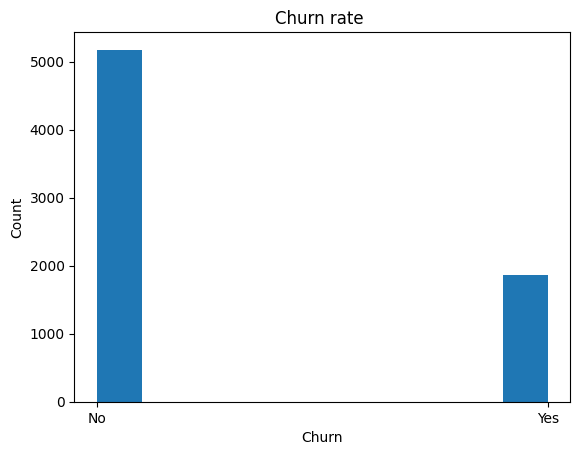

In [19]:
plt.hist(df['Churn'])
plt.title("Churn rate ")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [20]:
print("\nUnique values in categorical columns:")
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))



Unique values in categorical columns:

customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No               

### Qn 3. Source of Uncertanity

1. Total Charges has missing values : The column TotalCharges contains blank values that become NaN after conversion to numeric. These rows all have tenure = 0, so they likely represent new customers with no accumulated charges yet.

2. Churn is imbalancced: Only about 27% of customers churned. THis  means accuracy can be misleading, because if model just preddict "NO churn" everytime the accuraccy will be 73%


4. Some categorical values are structural, not ordinary categories.
Columns such as OnlineSecurity, OnlineBackup, TechSupport, StreamingTV, and StreamingMovies contain values like "No internet service". These should not be treated as missing values3. Tenure has zero values: The tenure column contains customers with tenure == 0. These customers may not have had enough time to churn, so their Churn = No label may be uncertain or censored.
 because they describe customers who do not have internet service.








# Task 2: Classification Experiment Who Will Churn?

Goal : goal is to find the best linear classifier for predicting churn.

## Qn1 and 2. Try Multiplee models and Comparisions

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


In [22]:
X = X.drop(['customerID'],axis=1)

The `TotalCharges` column is currently of type `object` and contains some blank values, as noted in the initial data exploration. This needs to be converted to a numeric type. Blank values will be coerced to `NaN` and then filled with 0, as they represent new customers with no charges yet (correlated with `tenure = 0`).

In [23]:
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
X['TotalCharges'] = X['TotalCharges'].fillna(0)

In [24]:
# Verify the data type and check for any remaining NaNs
print("TotalCharges dtype after conversion:", X['TotalCharges'].dtype)
print("Number of NaNs in TotalCharges after fillna:", X['TotalCharges'].isnull().sum())

TotalCharges dtype after conversion: float64
Number of NaNs in TotalCharges after fillna: 0


In [25]:
# Encode categorical
X = pd.get_dummies(X, drop_first=True)


In [26]:
# train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=36)
# stratify=y is used in the train_test_split function to ensure that the split between your training and
# testing sets preserves the same proportions of class labels found in your original data

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)

In [28]:
from sklearn.preprocessing import StandardScaler

# scale
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_test = le.transform(y_test)
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5634, 30)
(1409, 30)


In [29]:
y_test

array([0, 0, 0, ..., 1, 0, 1])

In [30]:
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, log_loss
from sklearn.metrics import RocCurveDisplay, roc_curve, auc


In [31]:
models = {
    'logistic': LogisticRegression(max_iter = 1000, solver= 'lbfgs'),
    'ridge': RidgeClassifier(alpha=1.0),
    'sgd': SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)

}

In [32]:


results = {}

for name, model in models.items():
    # train
    model.fit(X_train_scaled, y_train)

    # predict
    y_pred = model.predict(X_test_scaled)

    # initialize metrics that don't require probabilities
    current_model_results = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0)
    }

    # checking if the model has predict_proba before calculating ROC-AUC and Log Loss
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        current_model_results['ROC-AUC'] = roc_auc_score(y_test, y_pred_proba)
        current_model_results['Log Loss'] = log_loss(y_test, y_pred_proba)
    else:
        # For models without predict_proba, these metrics are not applicable
        current_model_results['ROC-AUC'] = np.nan
        current_model_results['Log Loss'] = np.nan

    results[name] = current_model_results

# Comparison table
results_df = pd.DataFrame(results).T
print(results_df.round(3))

          Accuracy  Precision  Recall     F1  ROC-AUC  Log Loss
logistic     0.796      0.678   0.551  0.608    0.850     0.426
ridge        0.789      0.674   0.516  0.585      NaN       NaN
sgd          0.783      0.649   0.533  0.585    0.837     0.442


In [33]:
best_model = models["logistic"]

## Qn 3. ROC and PR Curves and 200 customers threshols

Best model: here the best model seems to be logistic for this binary classification; with regards to ROC-AUC, balanced precision/recall, and low log loss

Threshold selection for 200 customers budget: The rentention teacm can call 200 customers per week. We sort all customer by predicted churn probablity descending and take the 200th score as our threshold

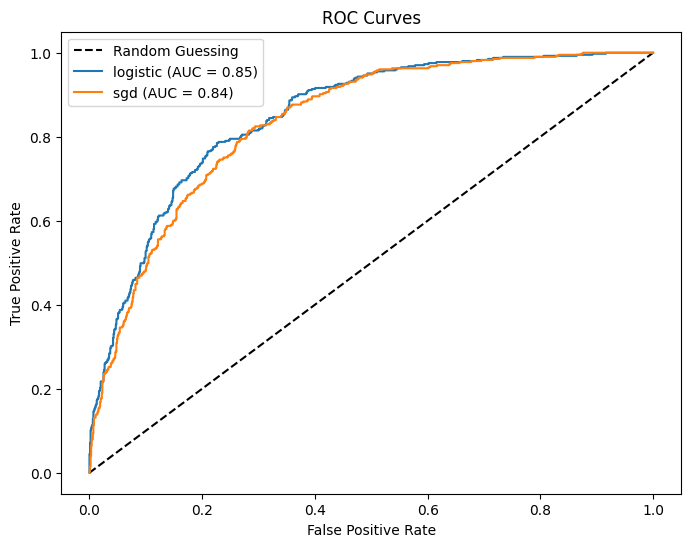

In [34]:

plt.figure(figsize=(8, 6))
# Plot the 50/50 baseline line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

# Loop through each model and plot its curve
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

        # Plot this model's curve
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

# Labels and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()


In [35]:
lr_prob_val = best_model.predict_proba(X_test_scaled)[:, 1]

## Qn4 Coefficient Analysis


In [36]:
feature_names = X.columns
coefs = best_model.coef_[0]

# Create table of features + coefficients
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
})

# Sort by strongest impact (absolute value)
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

# Top 15 most important features
top_features = coef_df.head(15)

print(top_features)

                                 feature  coefficient
1                                 tenure    -1.383676
25                     Contract_Two year    -0.624820
3                           TotalCharges     0.617520
10           InternetService_Fiber optic     0.589425
2                         MonthlyCharges    -0.532616
24                     Contract_One year    -0.264533
26                  PaperlessBilling_Yes     0.181559
9                      MultipleLines_Yes     0.176420
21                       StreamingTV_Yes     0.171094
23                   StreamingMovies_Yes     0.163623
28        PaymentMethod_Electronic check     0.140632
13                    OnlineSecurity_Yes    -0.132015
19                       TechSupport_Yes    -0.109634
6                         Dependents_Yes    -0.099124
16  DeviceProtection_No internet service    -0.073493


### Interpretation of Coefficients

Okay, so looking at the Logistic Regression model's coefficients tells us a lot about what makes customers churn. Basically, a positive coefficient means that feature makes churn *more likely*, and a negative one means it makes churn *less likely*.

From our `top_features` list, here's what stands out:

*   **`tenure` (Coefficient: -1.38)**: This is a huge factor! The longer a customer stays (higher tenure), the much lower their chance of churning. This makes total sense; loyal customers stick around.

*   **`Contract_Two year` (Coefficient: -0.62)**: If customers are on a two-year contract, they're way less likely to churn. It seems like committing to a longer contract keeps them from leaving, which is what we'd expect.

*   **`TotalCharges` (Coefficient: 0.62)**: This one is interesting. Higher `TotalCharges` actually means a higher chance of churn. At first, it sounds weird, right? But maybe it means for newer customers (low tenure) who get hit with big bills fast, they're more likely to leave. Or it could be that high-spending customers are just more attractive to competitors.

*   **`InternetService_Fiber optic` (Coefficient: 0.59)**: Customers with fiber optic internet are more likely to churn. This is important! Maybe there are problems with the fiber optic service itself, like reliability or customer support issues, or these customers are just more demanding and willing to switch if they're not happy.

*   **`MonthlyCharges` (Coefficient: -0.53)**: This was a surprise! Higher `MonthlyCharges` actually *decreases* the chance of churning. You'd think high bills would make people leave. Maybe customers paying more are getting premium services they really value, so they don't want to switch. We need to think about this alongside `TotalCharges` because their effects are different.

*   **`Contract_One year` (Coefficient: -0.26)**: Like the two-year contracts, one-year contracts also help reduce churn, but not as much as the two-year ones. Still, it helps keep customers.

*   **`PaperlessBilling_Yes` (Coefficient: 0.18)**: Customers who use paperless billing are a bit more likely to churn. This could mean they're more tech-savvy and active in managing their accounts, possibly making them more open to checking out other providers.

**What this means for the business:**

*   **Keep the long-timers**: We should really focus on keeping customers who've been with us for a while and those on longer contracts. Maybe offer special deals when their contracts are ending.
*   **Check the Fiber Optic**: We need to look closely at our fiber optic service. What are the common complaints? Fixing these could really cut down on churn.
*   **Understand Charges Better**: We need more analysis on `TotalCharges` vs. `MonthlyCharges`. It's not straightforward, and there might be complex relationships with `tenure` we're missing.
*   **Engage Paperless Users**: Even though paperless billing itself isn't a cause, customers using it might be a group that needs more proactive engagement or loyalty programs.